# Reading Order — Rows vs Columns vs Inside-Out Spiral (LSTM, 20-Way Coarse CIFAR-100)

Three LSTMs, identical except the order pixels are fed in:

- **row-major** — read row by row (the original).
- **column-major** — read each column top→bottom, left to right.
- **spiral-out** — start at the center pixel and spiral outward to the edges.

Each ordering is a permutation of the 1,024 pixels reshaped to the same `(32, 96)` tensor, so any
difference is due to reading order alone. Self-contained; trains three models (~6–9 min on a T4).


## 1. Setup

In [1]:
import subprocess
import sys


def _ensure(module_name: str, pip_name: str | None = None) -> None:
    try:
        __import__(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or module_name])


_ensure("datasets")
_ensure("sklearn", "scikit-learn")
_ensure("matplotlib")

In [2]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")

import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, top_k_accuracy_score

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print("tensorflow:", tf.__version__)

tensorflow: 2.20.0


In [3]:
# --- Run configuration (trains THREE models, one per reading order) ---
NUM_CLASSES = 20
SUBSET      = 20000       # None = full 50k; ~5000 to iterate fast.
EPOCHS      = 30
BATCH       = 128
HIDDEN      = 128
DROPOUT     = 0.3
LR          = 1e-3
print(f"classes={NUM_CLASSES}  subset={SUBSET}  epochs={EPOCHS}  batch={BATCH}  (x3 models)")

classes=20  subset=20000  epochs=30  batch=128  (x3 models)


## 2. Load CIFAR-100

In [4]:
ds = load_dataset("uoft-cs/cifar100")
train_split, test_split = ds["train"], ds["test"]
coarse_names = train_split.features["coarse_label"].names


def split_to_arrays(split):
    images = np.stack([np.asarray(row["img"].convert("RGB"), dtype=np.uint8) for row in split])
    coarse = np.asarray(split["coarse_label"], dtype=np.int64)
    return images, coarse


train_images, train_coarse = split_to_arrays(train_split)
test_images, test_coarse = split_to_arrays(test_split)
print("train:", train_images.shape, "| test:", test_images.shape, "| classes:", len(coarse_names))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

train: (50000, 32, 32, 3) | test: (10000, 32, 32, 3) | classes: 20


## 3. The Three Reading Orders

Flat pixel index is `row*32 + col`. **row-major** is the identity. **column-major** transposes it so
each timestep is a column. **spiral-out** reverses an outside→center spiral, so it begins at the center
pixel and ends at the corners.


In [5]:
N = 32

def build_spiral_index(n):
    """Outside -> center spiral (flat indices)."""
    order = []; top, bottom, left, right = 0, n - 1, 0, n - 1
    while top <= bottom and left <= right:
        for c in range(left, right + 1): order.append(top * n + c)
        top += 1
        for r in range(top, bottom + 1): order.append(r * n + right)
        right -= 1
        if top <= bottom:
            for c in range(right, left - 1, -1): order.append(bottom * n + c)
            bottom -= 1
        if left <= right:
            for r in range(bottom, top - 1, -1): order.append(r * n + left)
            left += 1
    return np.asarray(order, dtype=np.int64)


ROW_IDX     = np.arange(N * N)                          # original: row by row
COL_IDX     = np.arange(N * N).reshape(N, N).T.ravel()  # column by column (top->bottom)
SPIRAL_OUT  = build_spiral_index(N)[::-1].copy()        # center -> edges

ORDERINGS = {"row-major": ROW_IDX, "column-major": COL_IDX, "spiral-out": SPIRAL_OUT}
for name, idx in ORDERINGS.items():
    assert np.array_equal(np.sort(idx), np.arange(N * N)), f"{name} is not a valid permutation"


def to_sequence(images: np.ndarray, index: np.ndarray) -> np.ndarray:
    if images.ndim != 4 or images.shape[1:] != (32, 32, 3):
        raise ValueError(f"expected (N, 32, 32, 3); got {images.shape}")
    n = images.shape[0]
    flat = (images.astype(np.float32) / 255.0).reshape(n, 32 * 32, 3)
    return flat[:, index, :].reshape(n, 32, 96)


def make_sequence_pipeline(images, labels, index, *, batch_size, shuffle, shuffle_buffer=2048, seed=None):
    seq = to_sequence(images, index)
    ds = tf.data.Dataset.from_tensor_slices((seq, labels.astype(np.int64, copy=False)))
    if shuffle:
        ds = ds.shuffle(shuffle_buffer, seed=seed, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

PALETTE = {"row-major": "tab:blue", "column-major": "tab:orange", "spiral-out": "tab:green"}

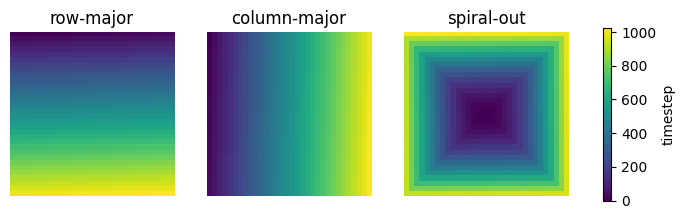

column-major timestep 0 (r,c): [(0, 0), (1, 0), (2, 0), (3, 0)] ...
spiral-out starts at (r,c): (16, 15) ends at: (0, 0)


In [6]:
# Read order per pixel: dark = read first, bright = read last.
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
im = None
for ax, (name, index) in zip(axes, ORDERINGS.items()):
    omap = np.empty(N * N, dtype=np.int64); omap[index] = np.arange(N * N)
    im = ax.imshow(omap.reshape(N, N), cmap="viridis"); ax.set_title(name); ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.7, label="timestep")
plt.show()
print("column-major timestep 0 (r,c):", [(int(i) // N, int(i) % N) for i in COL_IDX[:4]], "...")
print("spiral-out starts at (r,c):", (int(SPIRAL_OUT[0]) // N, int(SPIRAL_OUT[0]) % N),
      "ends at:", (int(SPIRAL_OUT[-1]) // N, int(SPIRAL_OUT[-1]) % N))

## 4. Stratified Subset + Split (shared by all three)

In [7]:
def stratified_subset(images, labels, *, subset_size, seed):
    if subset_size is None or subset_size >= labels.shape[0]:
        return images, labels
    rng = np.random.default_rng(seed)
    parts = []
    for cls in np.unique(labels):
        idx = np.flatnonzero(labels == cls)
        n_cls = min(max(1, round(subset_size * idx.size / labels.shape[0])), idx.size)
        parts.append(rng.choice(idx, size=n_cls, replace=False))
    sel = np.concatenate(parts)
    if sel.shape[0] > subset_size:
        sel = rng.choice(sel, size=subset_size, replace=False)
    rng.shuffle(sel)
    return images[sel], labels[sel]


def stratified_train_val_split(images, labels, *, val_fraction=0.1, seed=42):
    rng = np.random.default_rng(seed)
    tr, va = [], []
    for cls in np.unique(labels):
        idx = np.flatnonzero(labels == cls)
        rng.shuffle(idx)
        n_val = min(max(1, round(len(idx) * val_fraction)), max(len(idx) - 1, 1))
        va.append(idx[:n_val]); tr.append(idx[n_val:])
    tr, va = np.concatenate(tr), np.concatenate(va)
    rng.shuffle(tr); rng.shuffle(va)
    return images[tr], labels[tr], images[va], labels[va]

## 5. LSTM Model

In [8]:
keras = tf.keras
layers = tf.keras.layers


def build_lstm(num_classes=NUM_CLASSES, hidden_units=HIDDEN, dropout=DROPOUT) -> keras.Model:
    inputs = keras.Input(shape=(32, 96), name="sequence")
    x = layers.LSTM(hidden_units, activation="tanh")(inputs)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="probs")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="lstm")


build_lstm().summary()

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence (InputLayer)           │ (None, 32, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,780 (460.08 KB)

 Trainable params: 117,780 (460.08 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train All Three

Shared split, same architecture, same weight initialization (seed reset before each build), same schedule — only the ordering varies.

In [9]:
img_tr, y_tr_s = stratified_subset(train_images, train_coarse, subset_size=SUBSET, seed=SEED)
x_tr, y_tr, x_val, y_val = stratified_train_val_split(img_tr, y_tr_s, val_fraction=0.1, seed=SEED)
print(f"shared split: train {x_tr.shape[0]}  val {x_val.shape[0]}  test {test_images.shape[0]}")

y_true = test_coarse.astype(np.int64)
labels20 = list(range(NUM_CLASSES))
results = {}

for order_name, index in ORDERINGS.items():
    print(f"\n{'='*52}\nTraining: {order_name}\n{'='*52}")
    train_ds = make_sequence_pipeline(x_tr, y_tr, index, batch_size=BATCH, shuffle=True, seed=SEED)
    val_ds   = make_sequence_pipeline(x_val, y_val, index, batch_size=BATCH, shuffle=False)
    test_ds  = make_sequence_pipeline(test_images, test_coarse, index, batch_size=BATCH, shuffle=False)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    model = build_lstm()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3")],
    )
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)

    y_prob = model.predict(test_ds, verbose=0)
    y_pred = y_prob.argmax(axis=1)
    cm = confusion_matrix(y_true, y_pred, labels=labels20)
    results[order_name] = {
        "history":   history.history,
        "top1":      accuracy_score(y_true, y_pred),
        "top3":      top_k_accuracy_score(y_true, y_prob, k=3, labels=labels20),
        "top5":      top_k_accuracy_score(y_true, y_prob, k=5, labels=labels20),
        "macro_f1":  f1_score(y_true, y_pred, average="macro", zero_division=0),
        "per_class": cm.diagonal() / cm.sum(axis=1).clip(min=1),
    }
    r = results[order_name]
    print(f"  {order_name}: top-1={r['top1']:.3f}  top-3={r['top3']:.3f}  macro-F1={r['macro_f1']:.3f}")

shared split: train 18000  val 2000  test 10000

Training: row-major
Epoch 1/30
141/141 - 16s - 116ms/step - accuracy: 0.1375 - loss: 2.7905 - top3: 0.3182 - val_accuracy: 0.2155 - val_loss: 2.5538 - val_top3: 0.4440 - learning_rate: 0.0010
Epoch 2/30
141/141 - 14s - 99ms/step - accuracy: 0.2056 - loss: 2.5564 - top3: 0.4301 - val_accuracy: 0.2400 - val_loss: 2.4766 - val_top3: 0.4660 - learning_rate: 0.0010
Epoch 3/30
141/141 - 20s - 145ms/step - accuracy: 0.2389 - loss: 2.4588 - top3: 0.4726 - val_accuracy: 0.2525 - val_loss: 2.4244 - val_top3: 0.4835 - learning_rate: 0.0010
Epoch 4/30
141/141 - 22s - 154ms/step - accuracy: 0.2602 - loss: 2.3798 - top3: 0.5012 - val_accuracy: 0.2845 - val_loss: 2.3423 - val_top3: 0.5260 - learning_rate: 0.0010
Epoch 5/30
141/141 - 14s - 100ms/step - accuracy: 0.2782 - loss: 2.3286 - top3: 0.5258 - val_accuracy: 0.2845 - val_loss: 2.3195 - val_top3: 0.5260 - learning_rate: 0.0010
Epoch 6/30
141/141 - 21s - 145ms/step - accuracy: 0.2913 - loss: 2.2869 

## 7. Compare

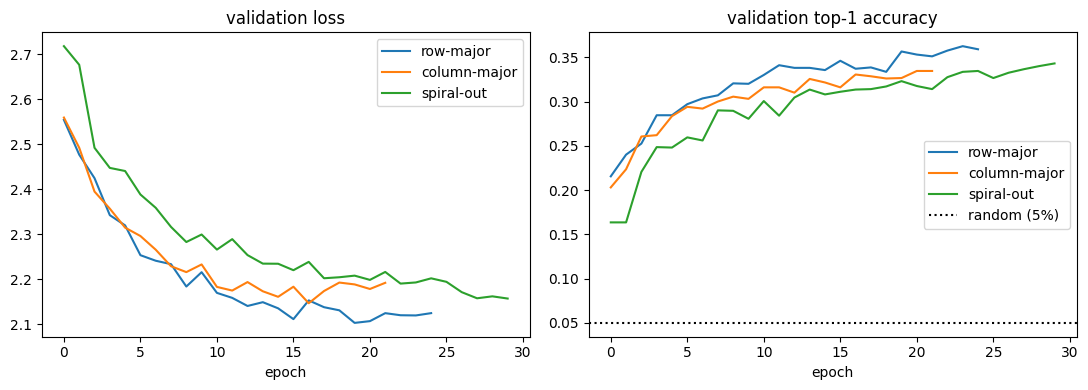

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, r in results.items():
    h = r["history"]
    ax[0].plot(h["val_loss"], color=PALETTE[name], label=name)
    ax[1].plot(h["val_accuracy"], color=PALETTE[name], label=name)
ax[0].set_title("validation loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].axhline(1 / NUM_CLASSES, color="black", ls=":", label="random (5%)")
ax[1].set_title("validation top-1 accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

ordering         top-1   top-3   top-5  macro-F1
------------------------------------------------
row-major        0.347   0.594   0.721     0.338
spiral-out       0.323   0.572   0.708     0.318
column-major     0.319   0.567   0.704     0.311


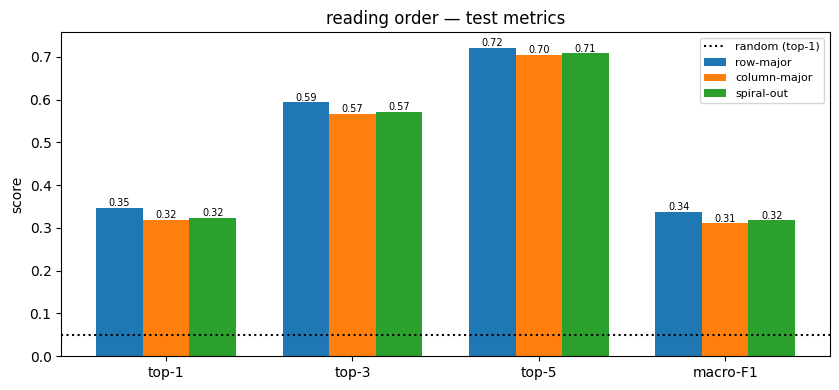

In [11]:
print(f"{'ordering':<14}{'top-1':>8}{'top-3':>8}{'top-5':>8}{'macro-F1':>10}")
print("-" * 48)
for name, r in sorted(results.items(), key=lambda kv: -kv[1]["top1"]):
    print(f"{name:<14}{r['top1']:>8.3f}{r['top3']:>8.3f}{r['top5']:>8.3f}{r['macro_f1']:>10.3f}")

metric_keys = ["top1", "top3", "top5", "macro_f1"]
metric_labels = ["top-1", "top-3", "top-5", "macro-F1"]
names = list(results.keys())
xs = np.arange(len(metric_keys)); width = 0.25
fig, ax = plt.subplots(figsize=(8.5, 4))
for i, name in enumerate(names):
    vals = [results[name][k] for k in metric_keys]
    bars = ax.bar(xs + (i - 1) * width, vals, width, label=name, color=PALETTE[name])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.004, f"{v:.2f}", ha="center", fontsize=7)
ax.axhline(1 / NUM_CLASSES, color="black", ls=":", label="random (top-1)")
ax.set_xticks(xs); ax.set_xticklabels(metric_labels); ax.set_ylabel("score")
ax.set_title("reading order — test metrics"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

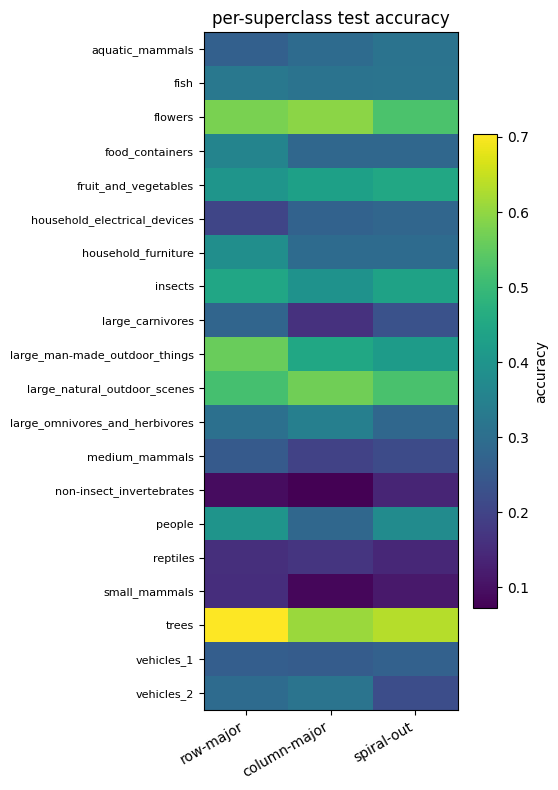

In [12]:
# Per-superclass accuracy across the three orderings.
mat = np.stack([results[name]["per_class"] for name in results], axis=1)   # (20, 3)
fig, ax = plt.subplots(figsize=(5.5, 8))
im = ax.imshow(mat, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(results))); ax.set_xticklabels(list(results.keys()), rotation=30, ha="right")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(coarse_names, fontsize=8)
ax.set_title("per-superclass test accuracy")
fig.colorbar(im, ax=ax, shrink=0.7, label="accuracy")
plt.tight_layout(); plt.show()

## Interpretation

Read the ranking off the metrics table and the val-accuracy curves. **row-major vs column-major** asks
whether the LSTM cares about reading horizontally vs vertically — if images had no orientation bias the
two would match, so any gap reflects real anisotropy in the data (and the per-class heatmap shows which
superclasses drive it). **spiral-out vs row-major** tests a different trajectory entirely: spiral-out
hands the LSTM the center first and the edges last, so because the final hidden state is weighted toward
the last timesteps, this model "ends" on the image border — the opposite emphasis from an outside→center
spiral.

Caveat: one seed is one run. Before claiming a winner, rerun with a few `SEED` values and confirm the
gap survives the noise.
